In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

In [76]:
infosys = yf.download("INFY.NS",start="2020-01-01", end="2026-03-01")
print(infosys)

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open    Volume
Ticker          INFY.NS      INFY.NS      INFY.NS      INFY.NS   INFY.NS
Date                                                                    
2020-01-01   633.151001   635.857714   629.456163   631.561378   2112415
2020-01-02   631.303589   636.545098   628.038384   634.912521   5658200
2020-01-03   641.013428   642.731962   630.616314   630.616314   7882938
2020-01-06   634.869629   647.715686   632.850372   641.099317   6519403
2020-01-07   625.460693   638.091881   623.054703   634.139272   7899363
...                 ...          ...          ...          ...       ...
2026-02-23  1327.500000  1352.000000  1318.000000  1352.000000  12887826
2026-02-24  1275.500000  1303.599976  1264.099976  1301.000000  27839061
2026-02-25  1290.099976  1323.599976  1286.199951  1286.199951  16669618
2026-02-26  1289.099976  1314.000000  1286.300049  1305.500000  11493914
2026-02-27  1300.099976  1335.000000  1294.199951  

In [77]:
infosys['return']=(infosys['Close']/infosys['Close'].shift(1))-1
print(infosys)

Price             Close         High          Low         Open    Volume  \
Ticker          INFY.NS      INFY.NS      INFY.NS      INFY.NS   INFY.NS   
Date                                                                       
2020-01-01   633.151001   635.857714   629.456163   631.561378   2112415   
2020-01-02   631.303589   636.545098   628.038384   634.912521   5658200   
2020-01-03   641.013428   642.731962   630.616314   630.616314   7882938   
2020-01-06   634.869629   647.715686   632.850372   641.099317   6519403   
2020-01-07   625.460693   638.091881   623.054703   634.139272   7899363   
...                 ...          ...          ...          ...       ...   
2026-02-23  1327.500000  1352.000000  1318.000000  1352.000000  12887826   
2026-02-24  1275.500000  1303.599976  1264.099976  1301.000000  27839061   
2026-02-25  1290.099976  1323.599976  1286.199951  1286.199951  16669618   
2026-02-26  1289.099976  1314.000000  1286.300049  1305.500000  11493914   
2026-02-27  

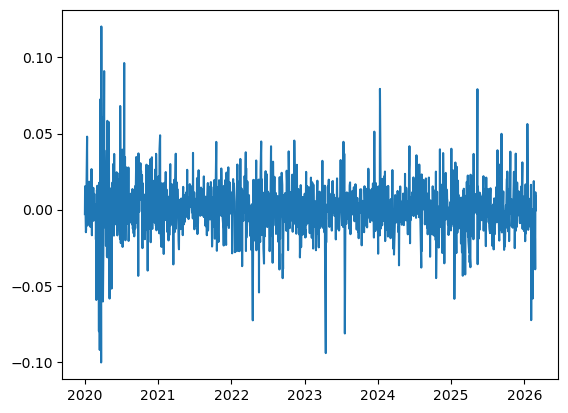

In [78]:
#infosys['return'].plot(figsize=(8,5))
plt.plot(infosys['return'])

Text(0.5, 1.0, 'Returns of Infosys')

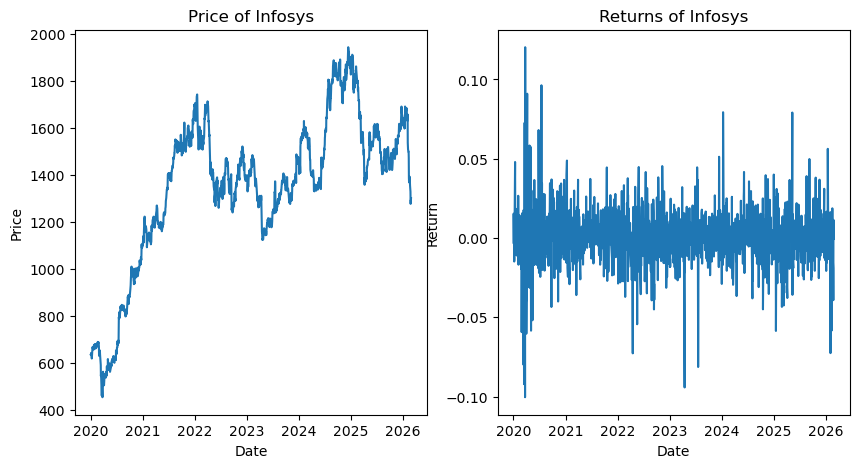

In [110]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(infosys['Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price of Infosys')

plt.subplot(122)
plt.plot(infosys['return'])
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('Returns of Infosys')

In [80]:
infosys['log_return'] = np.log(infosys['Close']/infosys['Close'].shift(1))
infosys

Price,Close,High,Low,Open,Volume,return,log_return
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,,
Date,,,,,,,
2020-01-01,633.151001,635.857714,629.456163,631.561378,2112415,NaN,NaN
2020-01-02,631.303589,636.545098,628.038384,634.912521,5658200,-0.002918,-0.002922
2020-01-03,641.013428,642.731962,630.616314,630.616314,7882938,0.015381,0.015264
2020-01-06,634.869629,647.715686,632.850372,641.099317,6519403,-0.009585,-0.009631
2020-01-07,625.460693,638.091881,623.054703,634.139272,7899363,-0.014820,-0.014931
...,...,...,...,...,...,...,...
2026-02-23,1327.500000,1352.000000,1318.000000,1352.000000,12887826,-0.018992,-0.019175
2026-02-24,1275.500000,1303.599976,1264.099976,1301.000000,27839061,-0.039171,-0.039959


Text(0.5, 1.0, 'Comparing returns and log returns')

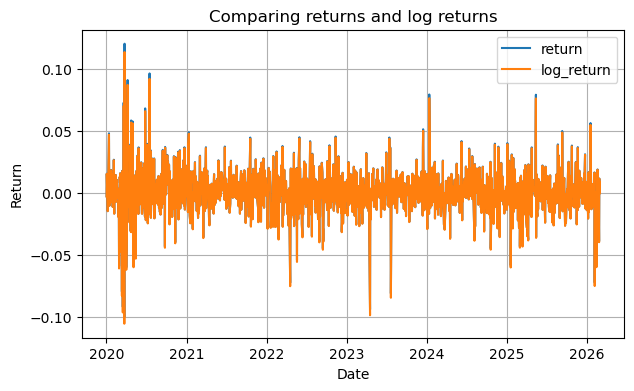

In [111]:
plt.figure(figsize=(7,4))
plt.plot(infosys['return'],label='return')
plt.plot(infosys['log_return'],label='log_return')
plt.grid(True)
plt.axis('tight')
plt.legend(loc=0)
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('Comparing returns and log returns')

In [82]:
short_tickers=['RELIANCE.NS','ASIANPAINT.NS','M&M.NS','AXISBANK.NS']

In [83]:
pf_short=pd.DataFrame()

for t in short_tickers:
    pf_short[t]=yf.download(t,start='2020-01-01',end='2026-03-01')['Close']
    
print(pf_short)    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

            RELIANCE.NS  ASIANPAINT.NS       M&M.NS  AXISBANK.NS
Date                                                            
2020-01-01   675.324158    1705.415649   509.727905   745.586914
2020-01-02   686.821228    1702.990234   512.815125   753.802612
2020-01-03   687.648865    1665.661865   506.070770   739.860840
2020-01-06   671.700684    1623.578125   498.233917   720.242737
2020-01-07   682.034607    1639.983521   500.276245   722.732361
...                 ...            ...          ...          ...
2026-02-23  1428.000000    2429.699951  3447.100098  1386.699951
2026-02-24  1428.800049    2413.100098  3433.199951  1387.599976
2026-02-25  1398.500000    2416.399902  3491.300049  1403.000000
2026-02-26  1406.800049    2394.899902  3484.600098  1395.500000
2026-02-27  1393.900024    2376.199951  3397.399902  1383.900024

[1528 rows x 4 columns]


In [84]:
pf_returns=(pf_short/pf_short.shift(1))-1

In [85]:
pf_returns=pf_returns[["RELIANCE.NS","M&M.NS"]]
pf_returns

,RELIANCE.NS,M&M.NS
Date,,
2020-01-01,NaN,NaN
2020-01-02,0.017025,0.006057
2020-01-03,0.001205,-0.013152
2020-01-06,-0.023192,-0.015486
2020-01-07,0.015385,0.004099
...,...,...
2026-02-23,0.006059,0.010050
2026-02-24,0.000560,-0.004032
2026-02-25,-0.021207,0.016923


In [86]:
pf_returns['RELIANCE.NS'].std()

0.017727986342704973

In [87]:
pf_returns['M&M.NS'].std()

0.020628348011210787

In [88]:
pf_returns['RELIANCE.NS'].std()*252**0.5

0.2814230586524811

In [89]:
pf_returns['M&M.NS'].std()*252**0.5

0.3274648727745455

In [90]:
pf_returns['RELIANCE.NS'].var()

0.0003142814997671341

In [91]:
pf_returns['M&M.NS'].var()

0.00042552874167162396

In [92]:
pf_returns['RELIANCE.NS'].var()*252

0.0791989379413178

In [93]:
pf_returns['M&M.NS'].var()*252

0.10723324290124923

In [94]:
cov_matrix_d=pf_returns.cov()
cov_matrix_d 

,RELIANCE.NS,M&M.NS
RELIANCE.NS,0.000314,0.000136
M&M.NS,0.000136,0.000426


In [95]:
corr_matrix=pf_returns.corr()
corr_matrix

,RELIANCE.NS,M&M.NS
RELIANCE.NS,1.000000,0.372712
M&M.NS,0.372712,1.000000


In [96]:
weights_1=np.array([0.5,0.5])
weights_2=np.array([0.3,0.7])

In [97]:
pf_returns_w1=np.dot(pf_returns[['RELIANCE.NS','M&M.NS']].mean()*252,weights_1)
pf_returns_w1

np.float64(0.2627814921559474)

In [98]:
pf_returns_w2=np.dot(pf_returns[['RELIANCE.NS','M&M.NS']].mean()*252,weights_2)
pf_returns_w2

np.float64(0.30425891462051247)

In [99]:
pf_var_1=np.dot(weights_1.T,np.dot(pf_returns.cov()*252,weights_1))
pf_var_1

np.float64(0.06378190954542774)

In [100]:
pf_var_2=np.dot(weights_2.T,np.dot(pf_returns.cov()*252,weights_2))
pf_var_2

np.float64(0.07409823947755102)

In [101]:
pf_var_3=np.dot(weights_2,np.dot(pf_returns.cov()*252,weights_2))
pf_var_3

np.float64(0.07409823947755102)

In [102]:
pf_volatility_1=(np.dot(weights_1.T,np.dot(pf_returns.cov()*252,weights_1)))**0.5
pf_volatility_1
print(str(round(pf_volatility_1,5)*100)+"%")

25.255%


In [103]:
pf_volatility_2=(np.dot(weights_2.T,np.dot(pf_returns.cov()*252,weights_2)))**0.5
pf_volatility_2
print(str(round(pf_volatility_2,5)*100)+"%")

27.221%


In [104]:
trial=(pf_returns[['RELIANCE.NS','M&M.NS']].mean())*252

In [105]:
pf_returns_we=np.dot(weights_1,trial)
print(f"{round(pf_returns_we*100,3)}%")

26.278%
